# Protein Model Chemistry Structural Reasoning

This notebook implements the prototype workflow specified in `specs/protein_model_chem/`.

It treats a protein structure as a residue-level structural constraint network, then evaluates a single mutation as a local compatibility perturbation. Outputs are research-use structural hypotheses only. They are not pathogenicity calls, clinical classifications, exact ddG estimates, molecular dynamics, or exact mutant conformations.

Default fixture: `FX-001` (`2LZM`, mutation `A:L99A`).

Core requirement coverage: `REQ-001` through `REQ-019`.

## 1. Setup And Configuration

This section defines the runtime configuration, fixture registry, logging helper, and dependency checks. MolViewSpec is optional visualization-only code; all data loading, scoring, interpretation, and validation sections must work without MolViewSpec.

In [1]:
from __future__ import annotations

import base64
import io
import json
import math
import re
import sys
import time
from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import requests

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError("matplotlib is required for static fallback figures") from exc

try:
    import networkx as nx
except Exception as exc:
    raise RuntimeError("networkx is required for interaction graph construction") from exc

try:
    from scipy.spatial import cKDTree
except Exception as exc:
    raise RuntimeError("scipy is required for distance queries") from exc

try:
    from Bio.PDB import MMCIFParser, PDBParser
    from Bio.Data import IUPACData
except Exception as exc:
    raise RuntimeError(
        "biopython is required for this notebook. Install with `%pip install biopython`."
    ) from exc

try:
    from IPython.display import HTML, IFrame, display
except Exception:
    HTML = IFrame = display = None

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

NOTEBOOK_START = time.time()
notebook_log: list[dict[str, Any]] = []


def log_event(level: str, message: str, **context: Any) -> None:
    record = {
        "time": datetime.now(timezone.utc).isoformat(),
        "level": level,
        "message": message,
        **context,
    }
    notebook_log.append(record)


CONFIG = {
    "structure_source_priority": ["pdbe", "alphafold"],
    "mutation_radius_angstrom": 8.0,
    "hbond_distance_cutoff_angstrom": 3.5,
    "hbond_angle_min_degrees": 120.0,
    "salt_bridge_cutoff_angstrom": 4.0,
    "hydrophobic_cutoff_angstrom": 5.0,
    "aromatic_cutoff_angstrom": 6.0,
    "disulfide_cutoff_angstrom": 2.2,
    "packing_cutoff_angstrom": 5.0,
    "steric_clash_cutoff_angstrom": 2.0,
    "af_low_confidence_threshold": 50.0,
    "af_high_confidence_threshold": 80.0,
    "interaction_weights": {
        "disulfide": 1.00,
        "salt_bridge": 0.75,
        "aromatic": 0.65,
        "hydrogen_bond": 0.60,
        "hydrophobic": 0.50,
        "vdw_packing": 0.40,
        "steric_clash": -1.00,
    },
}

INTERACTION_COLORS = {
    "hydrogen_bond": "blue",
    "salt_bridge": "red",
    "hydrophobic": "gold",
    "aromatic": "purple",
    "disulfide": "green",
    "steric_clash": "orange",
    "vdw_packing": "grey",
}

AA3_TO_1 = {k.upper(): v for k, v in IUPACData.protein_letters_3to1_extended.items()}
AA1_TO_3 = {v: k for k, v in AA3_TO_1.items()}
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")
HYDROPHOBIC = set("AVILMFWY")
AROMATIC = set("FWYH")
ACIDIC = {"ASP", "GLU"}
BASIC = {"LYS", "ARG", "HIS"}
DONOR_ACCEPTOR_ELEMENTS = {"N", "O", "S"}
BACKBONE_ATOMS = {"N", "CA", "C", "O", "OXT"}
SIDECHAIN_VOLUMES = {
    "A": 88.6, "R": 173.4, "N": 114.1, "D": 111.1, "C": 108.5,
    "Q": 143.8, "E": 138.4, "G": 60.1, "H": 153.2, "I": 166.7,
    "L": 166.7, "K": 168.6, "M": 162.9, "F": 189.9, "P": 112.7,
    "S": 89.0, "T": 116.1, "W": 227.8, "Y": 193.6, "V": 140.0,
}

FIXTURES = {
    "FX-001": {"source": "pdbe", "identifier": "2LZM", "mutation": "A:L99A", "role": "happy-path"},
    "FX-002": {"source": "afdb", "identifier": "P04637", "mutation": "A:M1A", "role": "afdb-low-confidence"},
    "FX-003": {"source": "pdbe", "identifier": "6M0J", "mutation": "B:K417N", "role": "interface"},
    "FX-004": {"source": "pdbe", "identifier": "6M0J", "mutation": "A:H374A", "role": "unsupported-context"},
    "FX-005": {"source": "pdbe", "identifier": "XXXX", "mutation": "A:L99A", "role": "invalid-id"},
    "FX-006": {"source": "pdbe", "identifier": "2LZM", "mutation": "A:W99A", "role": "mutation-mismatch"},
    "FX-007": {"source": "pdbe", "identifier": "6M0J", "mutation": "A:M1A", "role": "missing-residue"},
}

# Change this to run another pinned fixture.
FIXTURE_ID = "FX-001"
WRITE_EXPORTS = False
EXPORT_DIR = Path("protein_model_chem_exports")

fixture = FIXTURES[FIXTURE_ID]
structure_request = {
    "source": fixture["source"],
    "identifier": fixture["identifier"],
    "mutation_notation": fixture["mutation"],
    "source_preference": "manual",
    "format_hint": "mmcif",
}

analysis_status = {
    "fixture_id": FIXTURE_ID,
    "ok_to_parse": False,
    "ok_to_analyze_mutation": False,
    "ok_to_interpret": False,
    "errors": [],
    "warnings": [],
}

config_table = pd.DataFrame(
    [{"key": k, "value": json.dumps(v) if isinstance(v, dict) else v} for k, v in CONFIG.items()]
)
display(config_table) if display else print(config_table)

,key,value
0,structure_source_priority,"[pdbe, alphafold]"
1,mutation_radius_angstrom,8.0
2,hbond_distance_cutoff_angstrom,3.5
3,hbond_angle_min_degrees,120.0
4,salt_bridge_cutoff_angstrom,4.0
5,hydrophobic_cutoff_angstrom,5.0
6,aromatic_cutoff_angstrom,6.0
7,disulfide_cutoff_angstrom,2.2
8,packing_cutoff_angstrom,5.0
9,steric_clash_cutoff_angstrom,2.0


## 2. Retrieval And Provenance

The notebook retrieves either a public PDBe/PDB mmCIF file or an AlphaFold DB model plus confidence metadata. Retrieval failures are recorded in `analysis_status` and `notebook_log` so negative fixtures can run through the notebook without undefined variables.

In [2]:
def http_get_text(url: str, timeout: int = 30) -> str:
    response = requests.get(url, timeout=timeout)
    if not response.ok:
        raise RuntimeError(f"GET {url} failed with HTTP {response.status_code}")
    return response.text


def http_get_json(url: str, timeout: int = 30) -> Any:
    response = requests.get(url, timeout=timeout)
    if not response.ok:
        raise RuntimeError(f"GET {url} failed with HTTP {response.status_code}")
    return response.json()


def fetch_pdbe_structure(identifier: str) -> dict[str, Any]:
    pdb_id = identifier.upper()
    cif_url = f"https://files.rcsb.org/download/{pdb_id}.cif"
    metadata_url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb_id}"
    cif_text = http_get_text(cif_url)
    metadata = {}
    try:
        metadata = http_get_json(metadata_url)
    except Exception as exc:
        log_event("warning", "PDB metadata fetch failed; continuing with coordinates", identifier=pdb_id, error=str(exc))
    return {
        "source": "pdbe",
        "identifier": pdb_id,
        "structure_text": cif_text,
        "structure_url": cif_url,
        "structure_format": "mmcif",
        "metadata": metadata,
        "confidence_json": None,
        "retrieval_date": datetime.now(timezone.utc).isoformat(),
    }


def fetch_afdb_structure(identifier: str) -> dict[str, Any]:
    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{identifier}"
    payload = http_get_json(api_url)
    if not isinstance(payload, list) or not payload:
        raise RuntimeError(f"AFDB prediction endpoint returned no records for {identifier}")
    record = payload[0]
    cif_url = record.get("cifUrl") or record.get("modelCifUrl") or f"https://alphafold.ebi.ac.uk/files/AF-{identifier}-F1-model_v6.cif"
    confidence_url = record.get("plddtDocUrl") or record.get("confidenceUrl") or record.get("confidenceJsonUrl")
    structure_text = http_get_text(cif_url)
    confidence_json = None
    if confidence_url:
        try:
            confidence_json = http_get_json(confidence_url)
        except Exception as exc:
            log_event("warning", "AFDB confidence JSON fetch failed", identifier=identifier, url=confidence_url, error=str(exc))
    return {
        "source": "afdb",
        "identifier": record.get("entryId") or record.get("modelEntityId") or identifier,
        "structure_text": structure_text,
        "structure_url": cif_url,
        "structure_format": "mmcif",
        "metadata": record,
        "confidence_json": confidence_json,
        "confidence_url": confidence_url,
        "retrieval_date": datetime.now(timezone.utc).isoformat(),
    }


def validate_structure_request(request: dict[str, Any]) -> None:
    if request.get("source") not in {"pdbe", "afdb", "local"}:
        raise ValueError(f"Unsupported structure source: {request.get('source')}")
    if not request.get("identifier"):
        raise ValueError("Structure identifier is required")
    if request["source"] == "local":
        path = Path(request["identifier"])
        if not path.exists():
            raise FileNotFoundError(f"Local structure path does not exist: {path}")


structure_payload = {
    "source": structure_request["source"],
    "identifier": structure_request["identifier"],
    "structure_text": "",
    "structure_url": None,
    "structure_format": structure_request.get("format_hint", "mmcif"),
    "metadata": {},
    "confidence_json": None,
}
provenance = {}

try:
    validate_structure_request(structure_request)
    if structure_request["source"] == "pdbe":
        structure_payload = fetch_pdbe_structure(structure_request["identifier"])
    elif structure_request["source"] == "afdb":
        structure_payload = fetch_afdb_structure(structure_request["identifier"])
    else:
        path = Path(structure_request["identifier"])
        structure_payload = {
            "source": "local",
            "identifier": str(path),
            "structure_text": path.read_text(),
            "structure_url": None,
            "structure_format": path.suffix.lower().lstrip("."),
            "metadata": {},
            "confidence_json": None,
            "retrieval_date": datetime.now(timezone.utc).isoformat(),
        }
    provenance = {k: v for k, v in structure_payload.items() if k not in {"structure_text", "confidence_json"}}
    analysis_status["ok_to_parse"] = True
    log_event("info", "Structure retrieval succeeded", **provenance)
except Exception as exc:
    msg = f"Retrieval failed for {structure_request['source']}:{structure_request['identifier']}: {exc}"
    analysis_status["errors"].append(msg)
    log_event("error", msg)

pd.DataFrame([provenance or {"status": "retrieval_failed", "identifier": structure_request.get("identifier")}])

,source,identifier,structure_url,structure_format,metadata,retrieval_date
0,pdbe,2LZM,https://files.rcsb.org/download/2LZM.cif,mmcif,"{'audit_author': [{'name': 'Weaver, L.H.', 'pd...",2026-05-20T12:14:07.010593+00:00


## 3. Structure Parsing And Normalization

BioPython parses mmCIF/PDB coordinates into atom and residue tables. The residue table is the handoff object for mutation validation, interaction detection, graph construction, and visualization.

In [3]:
def one_letter(resname: str) -> str:
    return AA3_TO_1.get(str(resname).upper(), "X")


def parse_structure(structure_text: str, fmt: str, structure_id: str):
    handle = io.StringIO(structure_text)
    if fmt.lower() in {"cif", "mmcif", "bcif"}:
        parser = MMCIFParser(QUIET=True)
    elif fmt.lower() == "pdb":
        parser = PDBParser(QUIET=True)
    else:
        raise ValueError(f"Unsupported structure format: {fmt}")
    return parser.get_structure(structure_id, handle)


def atom_element(atom) -> str:
    element = getattr(atom, "element", "") or atom.get_name()[0]
    return str(element).strip().upper()


def build_atom_table(structure, source: str) -> pd.DataFrame:
    rows = []
    model = next(structure.get_models())
    for chain in model:
        for residue in chain:
            hetflag, resseq, icode = residue.id
            resname = residue.get_resname().strip().upper()
            for atom in residue:
                altloc = atom.get_altloc()
                rows.append({
                    "source": source,
                    "chain_id": chain.id,
                    "residue_number": int(resseq),
                    "insertion_code": "" if icode == " " else str(icode).strip(),
                    "hetero_flag": str(hetflag).strip(),
                    "residue_name": resname,
                    "one_letter_code": one_letter(resname),
                    "atom_name": atom.get_name().strip(),
                    "element": atom_element(atom),
                    "altloc": "" if altloc in {" ", ""} else altloc,
                    "occupancy": atom.get_occupancy(),
                    "bfactor": float(atom.get_bfactor()),
                    "x": float(atom.coord[0]),
                    "y": float(atom.coord[1]),
                    "z": float(atom.coord[2]),
                })
    return pd.DataFrame(rows)


def representative_coord(group: pd.DataFrame) -> tuple[float, float, float]:
    sidechain = group[~group["atom_name"].isin(BACKBONE_ATOMS)]
    coords = sidechain[["x", "y", "z"]].to_numpy() if len(sidechain) else group[group["atom_name"].eq("CA")][["x", "y", "z"]].to_numpy()
    if len(coords) == 0:
        coords = group[["x", "y", "z"]].to_numpy()
    return tuple(np.nanmean(coords, axis=0))


def build_residue_table(atom_table: pd.DataFrame, payload: dict[str, Any]) -> pd.DataFrame:
    if atom_table.empty:
        return pd.DataFrame()
    atom_table = atom_table.copy()
    protein_atoms = atom_table[atom_table["one_letter_code"].isin(STANDARD_AA)].copy()
    rows = []
    for key, group in protein_atoms.groupby(["chain_id", "residue_number", "insertion_code", "residue_name"], sort=False):
        chain_id, residue_number, insertion_code, residue_name = key
        ca = group[group["atom_name"].eq("CA")]
        rep = representative_coord(group)
        confidence_value = float(group["bfactor"].mean()) if payload["source"] == "afdb" else np.nan
        confidence_source = "mmCIF B-factor pLDDT fallback" if payload["source"] == "afdb" else "experimental metadata / B-factor"
        rows.append({
            "residue_uid": f"{chain_id}:{residue_number}{insertion_code}:{residue_name}",
            "source": payload["source"],
            "chain_id": chain_id,
            "residue_number": int(residue_number),
            "insertion_code": insertion_code,
            "residue_name": residue_name,
            "one_letter_code": one_letter(residue_name),
            "has_backbone": bool(set(group["atom_name"]).intersection({"N", "CA", "C", "O"})),
            "has_sidechain": bool(len(group[~group["atom_name"].isin(BACKBONE_ATOMS)])),
            "ca_x": float(ca.iloc[0]["x"]) if len(ca) else np.nan,
            "ca_y": float(ca.iloc[0]["y"]) if len(ca) else np.nan,
            "ca_z": float(ca.iloc[0]["z"]) if len(ca) else np.nan,
            "rep_x": float(rep[0]),
            "rep_y": float(rep[1]),
            "rep_z": float(rep[2]),
            "confidence_value": confidence_value,
            "confidence_source": confidence_source,
            "quality_flags": "",
        })
    residues = pd.DataFrame(rows)
    if payload["source"] == "afdb" and payload.get("confidence_json"):
        residues = map_afdb_confidence(residues, payload["confidence_json"])
    return residues


def map_afdb_confidence(residues: pd.DataFrame, confidence_json: Any) -> pd.DataFrame:
    out = residues.copy()
    try:
        if isinstance(confidence_json, list) and confidence_json:
            confidence_json = confidence_json[0]
        residue_numbers = confidence_json.get("residueNumber") or confidence_json.get("residue_number")
        scores = confidence_json.get("confidenceScore") or confidence_json.get("confidence_score")
        if residue_numbers and scores:
            score_map = {int(r): float(s) for r, s in zip(residue_numbers, scores)}
            out["confidence_value"] = out["residue_number"].map(score_map).fillna(out["confidence_value"])
            out["confidence_source"] = "AFDB confidence JSON"
    except Exception as exc:
        log_event("warning", "AFDB confidence mapping failed; using B-factor fallback", error=str(exc))
    return out


def summarize_quality(residue_table: pd.DataFrame, atom_table: pd.DataFrame, payload: dict[str, Any]) -> pd.DataFrame:
    rows = []
    if residue_table.empty:
        return pd.DataFrame([{"category": "parser", "message": "No protein residues parsed", "severity": "error"}])
    missing_ca = residue_table["ca_x"].isna().sum()
    if missing_ca:
        rows.append({"category": "coordinates", "message": f"{missing_ca} residues are missing CA coordinates", "severity": "warning"})
    if payload["source"] == "afdb":
        low = (residue_table["confidence_value"] < CONFIG["af_low_confidence_threshold"]).sum()
        rows.append({"category": "confidence", "message": f"{low} residues below pLDDT {CONFIG['af_low_confidence_threshold']}", "severity": "info"})
    hetero = atom_table[atom_table["hetero_flag"].astype(str).ne("")]
    context_names = sorted(set(hetero["residue_name"]) & {"ZN", "NAG", "CL", "MG", "CA", "HEM", "FAD", "NAD"})
    if context_names:
        rows.append({"category": "unsupported_context", "message": f"Non-polymer context detected: {', '.join(context_names)}", "severity": "warning"})
    return pd.DataFrame(rows or [{"category": "quality", "message": "No blocking quality issues detected", "severity": "info"}])


atom_table = pd.DataFrame()
residue_table = pd.DataFrame()
quality_report = pd.DataFrame()

if analysis_status["ok_to_parse"]:
    try:
        structure_obj = parse_structure(
            structure_payload["structure_text"],
            structure_payload["structure_format"],
            structure_payload["identifier"],
        )
        atom_table = build_atom_table(structure_obj, structure_payload["source"])
        residue_table = build_residue_table(atom_table, structure_payload)
        quality_report = summarize_quality(residue_table, atom_table, structure_payload)
        if residue_table.empty:
            raise RuntimeError("Parsed structure contains no standard amino-acid residues")
        log_event("info", "Structure parsing succeeded", residues=len(residue_table), atoms=len(atom_table))
    except Exception as exc:
        msg = f"Structure parsing failed: {exc}"
        analysis_status["errors"].append(msg)
        log_event("error", msg)

display(residue_table.head()) if display else print(residue_table.head())
display(quality_report) if display else print(quality_report)

,residue_uid,source,chain_id,residue_number,insertion_code,residue_name,one_letter_code,has_backbone,has_sidechain,ca_x,ca_y,ca_z,rep_x,rep_y,rep_z,confidence_value,confidence_source,quality_flags
0,A:1:MET,pdbe,A,1,,MET,M,True,True,43.783001,-1.951,8.984,44.452749,0.283000,7.706250,NaN,experimental metadata / B-factor,
1,A:2:ASN,pdbe,A,2,,ASN,N,True,True,40.653000,-0.795,10.918,41.606999,-0.904750,13.274500,NaN,experimental metadata / B-factor,
2,A:3:ILE,pdbe,A,3,,ILE,I,True,True,38.546001,2.322,11.353,36.713251,3.046250,11.649750,NaN,experimental metadata / B-factor,
3,A:4:PHE,pdbe,A,4,,PHE,F,True,True,40.751999,3.772,14.110,38.924999,2.962429,16.849286,NaN,experimental metadata / B-factor,
4,A:5:GLU,pdbe,A,5,,GLU,E,True,True,43.952999,3.364,12.152,45.313800,0.301400,12.262200,NaN,experimental metadata / B-factor,


,category,message,severity
0,quality,No blocking quality issues detected,info


## 4. Mutation Input And Validation

Mutation parsing accepts strings such as `R273H`, `A:W128A`, and `CHAIN_A:W128A`. Validation stops mutation analysis when the residue is absent or the requested wild-type residue does not match the structure.

In [4]:
def parse_mutation_notation(notation: str, default_chain: str | None = None) -> dict[str, Any]:
    raw = notation.strip()
    pattern = r"^(?:(?P<chain>[A-Za-z0-9_]+):)?(?P<wt>[A-Z])(?P<resnum>-?\d+)(?P<mut>[A-Z])$"
    match = re.match(pattern, raw)
    if not match:
        return {"raw_notation": raw, "parse_status": "error", "parse_error": "Expected notation like A:L99A or R273H"}
    chain = match.group("chain") or default_chain
    return {
        "raw_notation": raw,
        "parsed_chain_id": chain.replace("CHAIN_", "") if chain else None,
        "parsed_wild_type_residue": match.group("wt"),
        "parsed_residue_number": int(match.group("resnum")),
        "parsed_mutant_residue": match.group("mut"),
        "parse_status": "ok",
        "parse_error": "",
    }


def validate_mutation(residues: pd.DataFrame, notation: str) -> dict[str, Any]:
    if residues.empty:
        return {"valid": False, "error": "No residue table available for mutation validation"}
    default_chain = str(residues.iloc[0]["chain_id"])
    parsed = parse_mutation_notation(notation, default_chain=default_chain)
    if parsed.get("parse_status") != "ok":
        return {"valid": False, **parsed, "error": parsed.get("parse_error")}
    if parsed["parsed_mutant_residue"] not in STANDARD_AA or parsed["parsed_wild_type_residue"] not in STANDARD_AA:
        return {"valid": False, **parsed, "error": "Only standard amino acid one-letter codes are supported"}
    candidates = residues[
        (residues["chain_id"].astype(str) == str(parsed["parsed_chain_id"]))
        & (residues["residue_number"].astype(int) == int(parsed["parsed_residue_number"]))
    ]
    if candidates.empty:
        available = residues.groupby("chain_id")["residue_number"].agg(["min", "max", "count"]).reset_index().to_dict("records")
        return {"valid": False, **parsed, "error": "Mutation residue is absent or unresolved", "available_ranges": available}
    if len(candidates) > 1:
        return {"valid": False, **parsed, "error": "Mutation maps to multiple residues; insertion code handling required"}
    observed = candidates.iloc[0]["one_letter_code"]
    if observed != parsed["parsed_wild_type_residue"]:
        return {
            "valid": False,
            **parsed,
            "observed_residue": observed,
            "error": f"Wild-type mismatch: observed {observed}, requested {parsed['parsed_wild_type_residue']}",
        }
    row = candidates.iloc[0].to_dict()
    return {
        "valid": True,
        **parsed,
        "observed_residue": observed,
        "residue_uid": row["residue_uid"],
        "chain_id": row["chain_id"],
        "residue_number": int(row["residue_number"]),
        "wild_type_residue": observed,
        "mutant_residue": parsed["parsed_mutant_residue"],
        "confidence_value": row.get("confidence_value"),
        "error": "",
    }


mutation_spec = parse_mutation_notation(structure_request["mutation_notation"], default_chain=None)
mutation_validation = validate_mutation(residue_table, structure_request["mutation_notation"])
analysis_status["ok_to_analyze_mutation"] = bool(mutation_validation.get("valid"))
if mutation_validation.get("valid"):
    log_event("info", "Mutation validation succeeded", mutation=structure_request["mutation_notation"])
else:
    log_event("warning", "Mutation validation failed", mutation=structure_request["mutation_notation"], error=mutation_validation.get("error"))

pd.DataFrame([mutation_validation])

,valid,raw_notation,parsed_chain_id,parsed_wild_type_residue,parsed_residue_number,parsed_mutant_residue,parse_status,parse_error,observed_residue,residue_uid,chain_id,residue_number,wild_type_residue,mutant_residue,confidence_value,error
0,True,A:L99A,A,L,99,A,ok,,L,A:99:LEU,A,99,L,A,NaN,


## 5. Wild-Type Interaction Detection

Interactions are heuristic structural compatibility constraints, not physical free energies. Each record carries geometry evidence, confidence, and relative weight fields required by the data contract.

In [5]:
def coord_array(row, cols=("rep_x", "rep_y", "rep_z")) -> np.ndarray:
    return np.array([row[c] for c in cols], dtype=float)


def distance(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))


def confidence_factor_for_residues(a: pd.Series, b: pd.Series) -> float:
    vals = []
    for row in [a, b]:
        val = row.get("confidence_value")
        if pd.notna(val):
            vals.append(float(val) / 100.0)
    if vals:
        return float(np.clip(np.nanmean(vals), 0.0, 1.0))
    return 0.85


def make_interaction(idx: int, a: pd.Series, b: pd.Series, interaction_type: str, metric: float, threshold: str, geometry_confidence: float, evidence_note: str, angle: float | None = None) -> dict[str, Any]:
    base = CONFIG["interaction_weights"][interaction_type]
    conf_factor = confidence_factor_for_residues(a, b)
    burial = 0.5
    coop = 0.5
    rel = base * geometry_confidence * burial * conf_factor * coop
    return {
        "interaction_id": f"I{idx:05d}",
        "residue_uid_a": a["residue_uid"],
        "residue_uid_b": b["residue_uid"],
        "chain_id_a": a["chain_id"],
        "chain_id_b": b["chain_id"],
        "residue_label_a": f"{a['chain_id']}:{a['one_letter_code']}{a['residue_number']}",
        "residue_label_b": f"{b['chain_id']}:{b['one_letter_code']}{b['residue_number']}",
        "interaction_type": interaction_type,
        "geometry_metric": metric,
        "threshold": threshold,
        "passes_threshold": True,
        "geometry_confidence": float(np.clip(geometry_confidence, 0, 1)),
        "burial_factor": burial,
        "confidence_factor": conf_factor,
        "cooperativity_factor": coop,
        "relative_weight": float(rel),
        "structure_confidence": "low" if conf_factor < 0.5 else ("high" if conf_factor >= 0.8 else "moderate"),
        "interaction_confidence": "low" if geometry_confidence < 0.5 or conf_factor < 0.5 else ("high" if geometry_confidence >= 0.8 and conf_factor >= 0.8 else "moderate"),
        "evidence_note": evidence_note,
        "directionality": "",
        "atom_ids": "",
        "distance_angstrom": metric,
        "angle_degrees": np.nan if angle is None else angle,
        "burial_proxy": burial,
    }


def detect_residue_level_interactions(residues: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if residues.empty:
        return pd.DataFrame()
    reps = residues[["rep_x", "rep_y", "rep_z"]].to_numpy(float)
    idx = 1
    for i in range(len(residues)):
        a = residues.iloc[i]
        for j in range(i + 1, len(residues)):
            b = residues.iloc[j]
            if a["chain_id"] == b["chain_id"] and abs(int(a["residue_number"]) - int(b["residue_number"])) <= 1:
                continue
            d = distance(reps[i], reps[j])
            if a["residue_name"] == "CYS" and b["residue_name"] == "CYS" and d <= CONFIG["disulfide_cutoff_angstrom"]:
                rows.append(make_interaction(idx, a, b, "disulfide", d, "<=2.2A SG-SG proxy", 0.95, "Cysteine residues are close enough for disulfide proxy")); idx += 1
            if a["residue_name"] in ACIDIC.union(BASIC) and b["residue_name"] in ACIDIC.union(BASIC):
                opposite = (a["residue_name"] in ACIDIC and b["residue_name"] in BASIC) or (a["residue_name"] in BASIC and b["residue_name"] in ACIDIC)
                if opposite and d <= CONFIG["salt_bridge_cutoff_angstrom"]:
                    rows.append(make_interaction(idx, a, b, "salt_bridge", d, "<=4.0A charged centroid proxy", 0.75, "Opposite charged residues within salt-bridge cutoff")); idx += 1
            if a["one_letter_code"] in HYDROPHOBIC and b["one_letter_code"] in HYDROPHOBIC and d <= CONFIG["hydrophobic_cutoff_angstrom"]:
                rows.append(make_interaction(idx, a, b, "hydrophobic", d, "<=5.0A sidechain centroid proxy", 0.70, "Hydrophobic residues within packing cutoff")); idx += 1
            if a["one_letter_code"] in AROMATIC and b["one_letter_code"] in AROMATIC and d <= CONFIG["aromatic_cutoff_angstrom"]:
                rows.append(make_interaction(idx, a, b, "aromatic", d, "<=6.0A aromatic centroid proxy", 0.65, "Aromatic residues within ring-centroid proxy cutoff")); idx += 1
            if d <= CONFIG["packing_cutoff_angstrom"]:
                rows.append(make_interaction(idx, a, b, "vdw_packing", d, "<=5.0A local packing proxy", 0.50, "Residues are close enough for local packing contact")); idx += 1
            if (a["one_letter_code"] in set("STNQDEKRHYCW") or b["one_letter_code"] in set("STNQDEKRHYCW")) and d <= CONFIG["hbond_distance_cutoff_angstrom"]:
                rows.append(make_interaction(idx, a, b, "hydrogen_bond", d, "<=3.5A donor/acceptor centroid proxy; angle unavailable", 0.45, "Distance-only hydrogen bond proxy; no hydrogens/bond graph used")); idx += 1
    return pd.DataFrame(rows)


def detect_atom_clashes(atom_table: pd.DataFrame, residues: pd.DataFrame) -> pd.DataFrame:
    if atom_table.empty or residues.empty:
        return pd.DataFrame()
    protein_atoms = atom_table[atom_table["one_letter_code"].isin(STANDARD_AA)].copy()
    coords = protein_atoms[["x", "y", "z"]].to_numpy(float)
    if len(coords) == 0:
        return pd.DataFrame()
    tree = cKDTree(coords)
    pairs = tree.query_pairs(CONFIG["steric_clash_cutoff_angstrom"])
    rows = []
    idx = 1
    residue_lookup = residues.set_index(["chain_id", "residue_number", "insertion_code", "residue_name"])
    for i, j in list(pairs)[:5000]:
        ai = protein_atoms.iloc[i]
        aj = protein_atoms.iloc[j]
        same_residue = (ai["chain_id"], ai["residue_number"], ai["insertion_code"]) == (aj["chain_id"], aj["residue_number"], aj["insertion_code"])
        if same_residue:
            continue
        if ai["chain_id"] == aj["chain_id"] and abs(int(ai["residue_number"]) - int(aj["residue_number"])) <= 1:
            continue
        key_a = (ai["chain_id"], ai["residue_number"], ai["insertion_code"], ai["residue_name"])
        key_b = (aj["chain_id"], aj["residue_number"], aj["insertion_code"], aj["residue_name"])
        if key_a not in residue_lookup.index or key_b not in residue_lookup.index:
            continue
        a = residue_lookup.loc[key_a]
        b = residue_lookup.loc[key_b]
        d = distance(coords[i], coords[j])
        rows.append(make_interaction(idx, a, b, "steric_clash", d, "<2.0A heavy atom proxy", 0.75, f"Heavy atom clash proxy: {ai['atom_name']}-{aj['atom_name']}"))
        idx += 1
    return pd.DataFrame(rows)


wt_interactions = pd.DataFrame()
if not residue_table.empty:
    residue_interactions = detect_residue_level_interactions(residue_table)
    clash_interactions = detect_atom_clashes(atom_table, residue_table)
    wt_interactions = pd.concat([residue_interactions, clash_interactions], ignore_index=True)
    if not wt_interactions.empty:
        wt_interactions["interaction_id"] = [f"I{i+1:05d}" for i in range(len(wt_interactions))]
    log_event("info", "WT interaction detection complete", interactions=len(wt_interactions))

display(wt_interactions.head(20)) if display else print(wt_interactions.head(20))

,interaction_id,residue_uid_a,residue_uid_b,chain_id_a,chain_id_b,residue_label_a,residue_label_b,interaction_type,geometry_metric,threshold,passes_threshold,geometry_confidence,burial_factor,confidence_factor,cooperativity_factor,relative_weight,structure_confidence,interaction_confidence,evidence_note,directionality,atom_ids,distance_angstrom,angle_degrees,burial_proxy
0,I00001,A:1:MET,A:5:GLU,A,A,A:M1,A:E5,vdw_packing,4.636640,<=5.0A local packing proxy,True,0.50,0.5,0.85,0.5,0.042500,high,moderate,Residues are close enough for local packing co...,,,4.636640,NaN,0.5
1,I00002,A:1:MET,A:158:TRP,A,A,A:M1,A:W158,hydrophobic,4.342130,<=5.0A sidechain centroid proxy,True,0.70,0.5,0.85,0.5,0.074375,high,moderate,Hydrophobic residues within packing cutoff,,,4.342130,NaN,0.5
2,I00003,A:1:MET,A:158:TRP,A,A,A:M1,A:W158,vdw_packing,4.342130,<=5.0A local packing proxy,True,0.50,0.5,0.85,0.5,0.042500,high,moderate,Residues are close enough for local packing co...,,,4.342130,NaN,0.5
3,I00004,A:2:ASN,A:5:GLU,A,A,A:N2,A:E5,vdw_packing,4.027396,<=5.0A local packing proxy,True,0.50,0.5,0.85,0.5,0.042500,high,moderate,Residues are close enough for local packing co...,,,4.027396,NaN,0.5
4,I00005,A:3:ILE,A:97:CYS,A,A,A:I3,A:C97,vdw_packing,4.433385,<=5.0A local packing proxy,True,0.50,0.5,0.85,0.5,0.042500,high,moderate,Residues are close enough for local packing co...,,,4.433385,NaN,0.5
5,I00006,A:3:ILE,A:100:ILE,A,A,A:I3,A:I100,hydrophobic,4.655012,<=5.0A sidechain centroid proxy,True,0.70,0.5,0.85,0.5,0.074375,high,moderate,Hydrophobic residues within packing cutoff,,,4.655012,NaN,0.5
6,I00007,A:3:ILE,A:100:ILE,A,A,A:I3,A:I100,vdw_packing,4.655012,<=5.0A local packing proxy,True,0.50,0.5,0.85,0.5,0.042500,high,moderate,Residues are close enough for local packing co...,,,4.655012,NaN,0.5
7,I00008,A:4:PHE,A:67:PHE,A,A,A:F4,A:F67,aromatic,5.390579,<=6.0A aromatic centroid proxy,True,0.65,0.5,0.85,0.5,0.089781,high,moderate,Aromatic residues within ring-centroid proxy c...,,,5.390579,NaN,0.5
8,I00009,A:4:PHE,A:71:VAL,A,A,A:F4,A:V71,hydrophobic,4.529766,<=5.0A sidechain centroid proxy,True,0.70,0.5,0.85,0.5,0.074375,high,moderate,Hydrophobic residues within packing cutoff,,,4.529766,NaN,0.5
9,I00010,A:4:PHE,A:71:VAL,A,A,A:F4,A:V71,vdw_packing,4.529766,<=5.0A local packing proxy,True,0.50,0.5,0.85,0.5,0.042500,high,moderate,Residues are close enough for local packing co...,,,4.529766,NaN,0.5


## 6. Interaction Graph And Confidence Summaries

The graph is a weighted residue MultiGraph. Metrics are transparent descriptors used for interpretation, not proof of biological importance.

In [6]:
def build_interaction_graph(interactions: pd.DataFrame, residues: pd.DataFrame) -> nx.MultiGraph:
    graph = nx.MultiGraph()
    for _, row in residues.iterrows():
        graph.add_node(
            row["residue_uid"],
            chain_id=row["chain_id"],
            residue_label=f"{row['chain_id']}:{row['one_letter_code']}{row['residue_number']}",
            residue_name=row["residue_name"],
            confidence_value=row.get("confidence_value"),
            mutation_site=False,
        )
    for _, edge in interactions.iterrows():
        graph.add_edge(
            edge["residue_uid_a"],
            edge["residue_uid_b"],
            key=edge["interaction_id"],
            interaction_type=edge["interaction_type"],
            interaction_confidence=edge["interaction_confidence"],
            geometry_confidence=edge["geometry_confidence"],
            burial_factor=edge["burial_factor"],
            confidence_factor=edge["confidence_factor"],
            cooperativity_factor=edge["cooperativity_factor"],
            relative_weight=edge["relative_weight"],
            evidence_note=edge["evidence_note"],
        )
    return graph


def compute_network_metrics(graph: nx.MultiGraph, mutation_uid: str | None) -> pd.DataFrame:
    rows = []
    simple = nx.Graph()
    for u, v, data in graph.edges(data=True):
        weight = abs(float(data.get("relative_weight", 0.0)))
        if simple.has_edge(u, v):
            simple[u][v]["weight"] += weight
        else:
            simple.add_edge(u, v, weight=weight)
    simple.add_nodes_from(graph.nodes())
    degree = dict(graph.degree())
    weighted_degree = {n: 0.0 for n in graph.nodes()}
    for u, v, data in graph.edges(data=True):
        weighted_degree[u] += abs(float(data.get("relative_weight", 0.0)))
        weighted_degree[v] += abs(float(data.get("relative_weight", 0.0)))
    try:
        betweenness = nx.betweenness_centrality(simple, weight="weight", normalized=True) if len(simple) else {}
    except Exception:
        betweenness = {n: np.nan for n in graph.nodes()}
    clustering = nx.clustering(simple, weight="weight") if len(simple) else {}
    for node in graph.nodes():
        rows.append({
            "residue_uid": node,
            "degree": degree.get(node, 0),
            "weighted_degree": weighted_degree.get(node, 0.0),
            "betweenness_centrality": betweenness.get(node, np.nan),
            "clustering_coefficient": clustering.get(node, np.nan),
            "is_mutation_site": bool(node == mutation_uid),
        })
    return pd.DataFrame(rows)


mutation_uid = mutation_validation.get("residue_uid") if mutation_validation.get("valid") else None
wt_graph = build_interaction_graph(wt_interactions, residue_table) if not residue_table.empty else nx.MultiGraph()
if mutation_uid in wt_graph:
    wt_graph.nodes[mutation_uid]["mutation_site"] = True
wt_network_metrics = compute_network_metrics(wt_graph, mutation_uid)
confidence_summary = {
    "structure_confidence": "unknown",
    "low_confidence_residue_count": 0,
    "unsupported_context": [],
}
if not residue_table.empty:
    if structure_payload["source"] == "afdb":
        low_count = int((residue_table["confidence_value"] < CONFIG["af_low_confidence_threshold"]).sum())
        confidence_summary = {
            "structure_confidence": "low-mixed" if low_count else "moderate-high",
            "low_confidence_residue_count": low_count,
            "unsupported_context": quality_report[quality_report["category"].eq("unsupported_context")]["message"].tolist() if not quality_report.empty else [],
        }
    else:
        confidence_summary = {
            "structure_confidence": "experimental-provenance",
            "low_confidence_residue_count": 0,
            "unsupported_context": quality_report[quality_report["category"].eq("unsupported_context")]["message"].tolist() if not quality_report.empty else [],
        }

display(wt_network_metrics.sort_values("is_mutation_site", ascending=False).head(10)) if display else print(wt_network_metrics.head())
pd.DataFrame([confidence_summary])

,residue_uid,degree,weighted_degree,betweenness_centrality,clustering_coefficient,is_mutation_site
98,A:99:LEU,0,0.000000,0.000000,0.000000,True
0,A:1:MET,3,0.159375,0.000909,0.000000,False
112,A:113:GLY,0,0.000000,0.000000,0.000000,False
105,A:106:MET,1,0.042500,0.000000,0.000000,False
106,A:107:GLY,0,0.000000,0.000000,0.000000,False
107,A:108:GLU,2,0.085000,0.000606,0.000000,False
108,A:109:THR,0,0.000000,0.000000,0.000000,False
109,A:110:GLY,1,0.042500,0.000000,0.000000,False
110,A:111:VAL,4,0.233750,0.000151,0.000000,False
111,A:112:ALA,4,0.201875,0.000379,0.122494,False


,structure_confidence,low_confidence_residue_count,unsupported_context
0,experimental-provenance,0,[]


## 7. Mutation Perturbation

The mutation model is intentionally conservative: sidechain substitution only, no global minimization, no conformational sampling, and local recomputation within 8 Angstrom. Outputs are compatibility signals, not exact mutant structures.

In [7]:
def mutation_neighborhood_residue_uids(residues: pd.DataFrame, mutation_uid: str, radius_angstrom: float | None = None) -> set[str]:
    if residues.empty or not mutation_uid or mutation_uid not in set(residues["residue_uid"]):
        return set()
    radius = float(CONFIG["mutation_radius_angstrom"] if radius_angstrom is None else radius_angstrom)
    center = residues.loc[residues["residue_uid"].eq(mutation_uid), ["rep_x", "rep_y", "rep_z"]].iloc[0].to_numpy(float)
    coords = residues[["rep_x", "rep_y", "rep_z"]].to_numpy(float)
    distances = np.linalg.norm(coords - center, axis=1)
    neighborhood = residues.loc[distances <= radius, "residue_uid"].tolist()
    return set(neighborhood)


def local_interactions_for_mutation(residues: pd.DataFrame, interactions: pd.DataFrame, mutation_uid: str, radius_angstrom: float | None = None) -> pd.DataFrame:
    if interactions.empty or not mutation_uid:
        return pd.DataFrame(columns=interactions.columns)
    neighborhood_uids = mutation_neighborhood_residue_uids(residues, mutation_uid, radius_angstrom)
    if not neighborhood_uids:
        return pd.DataFrame(columns=interactions.columns)
    mask = interactions["residue_uid_a"].isin(neighborhood_uids) | interactions["residue_uid_b"].isin(neighborhood_uids)
    return interactions.loc[mask].copy()


def estimate_mutant_compatibility(residues: pd.DataFrame, interactions: pd.DataFrame, validation: dict[str, Any], metrics: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not validation.get("valid"):
        return pd.DataFrame(), pd.DataFrame()
    mutation_uid = validation["residue_uid"]
    wt = validation["wild_type_residue"]
    mut = validation["mutant_residue"]
    local = local_interactions_for_mutation(residues, interactions, mutation_uid)
    wt_volume = SIDECHAIN_VOLUMES.get(wt, np.nan)
    mut_volume = SIDECHAIN_VOLUMES.get(mut, np.nan)
    volume_delta = mut_volume - wt_volume if pd.notna(wt_volume) and pd.notna(mut_volume) else np.nan
    rows = []
    delta_id = 1
    weakened = 0
    gained_clashes = 0
    for _, row in local.iterrows():
        itype = row["interaction_type"]
        signal = None
        if itype in {"hydrophobic", "vdw_packing", "aromatic"} and pd.notna(volume_delta) and volume_delta < -35:
            signal = "packing_change"
            weakened += 1
            interp = f"{wt}->{mut} substantially reduces sidechain volume near a {itype} contact."
        elif itype == "salt_bridge" and mut not in "DEKRH":
            signal = "lost_interaction"
            interp = f"{wt}->{mut} may remove charged-sidechain compatibility for a salt bridge."
        elif itype == "hydrogen_bond" and mut not in "STNQDEKRHYCW":
            signal = "weakened_interaction"
            interp = f"{wt}->{mut} may reduce donor/acceptor compatibility for a hydrogen-bond proxy."
        elif itype == "disulfide" and wt == "C" and mut != "C":
            signal = "lost_interaction"
            interp = "Cysteine substitution removes disulfide compatibility."
        if signal:
            rows.append({
                "delta_id": f"D{delta_id:04d}",
                "residue_uid": mutation_uid,
                "mutation": validation["raw_notation"],
                "signal_type": signal,
                "wt_evidence": row["evidence_note"],
                "mutant_estimate": interp,
                "lost_interactions": 1 if signal == "lost_interaction" else 0,
                "gained_interactions": 0,
                "gained_clashes": 0,
                "packing_change": "reduced" if signal == "packing_change" else "",
                "centrality_delta": np.nan,
                "severity": "",
                "observation_text": f"WT local interaction detected: {row['interaction_type']} with {row['residue_label_a']} / {row['residue_label_b']}.",
                "interpretation_text": interp,
                "confidence": row["interaction_confidence"],
            })
            delta_id += 1
    if pd.notna(volume_delta) and volume_delta > 45 and len(local) >= 4:
        gained_clashes += 1
        rows.append({
            "delta_id": f"D{delta_id:04d}",
            "residue_uid": mutation_uid,
            "mutation": validation["raw_notation"],
            "signal_type": "new_clash",
            "wt_evidence": f"{len(local)} local WT interactions within mutation neighborhood.",
            "mutant_estimate": f"{wt}->{mut} increases sidechain volume by {volume_delta:.1f}; steric incompatibility is possible.",
            "lost_interactions": 0,
            "gained_interactions": 0,
            "gained_clashes": 1,
            "packing_change": "expanded",
            "centrality_delta": np.nan,
            "severity": "",
            "observation_text": "The mutant sidechain is substantially larger than WT in a contacted local environment.",
            "interpretation_text": "This is consistent with possible local steric pressure.",
            "confidence": "moderate",
        })
    if not rows and validation.get("valid"):
        rows.append({
            "delta_id": "D0001",
            "residue_uid": mutation_uid,
            "mutation": validation["raw_notation"],
            "signal_type": "confidence_warning" if local.empty else "network_change",
            "wt_evidence": f"{len(local)} local WT interactions detected.",
            "mutant_estimate": "No rule-supported local perturbation signal detected by the v1 sidechain-compatibility model.",
            "lost_interactions": 0,
            "gained_interactions": 0,
            "gained_clashes": 0,
            "packing_change": "",
            "centrality_delta": 0.0,
            "severity": "",
            "observation_text": "The mutation site was parsed, but v1 rules did not detect a strong local perturbation.",
            "interpretation_text": "Absence of a detected signal is not proof of no structural effect.",
            "confidence": "low" if local.empty else "moderate",
        })
    delta = pd.DataFrame(rows)
    if not delta.empty and mutation_uid in set(metrics["residue_uid"]):
        local_degree = float(metrics.loc[metrics["residue_uid"].eq(mutation_uid), "weighted_degree"].iloc[0])
        delta["centrality_delta"] = delta["centrality_delta"].fillna(-min(local_degree, abs(delta["relative_weight"].sum()) if "relative_weight" in delta else local_degree))
    mutant_interactions = local.copy()
    return mutant_interactions, delta


def rank_structural_disruption(delta: pd.DataFrame, validation: dict[str, Any], confidence: dict[str, Any]) -> dict[str, Any]:
    if not validation.get("valid"):
        return {"severity": "not_applicable", "rationale": validation.get("error", "mutation not valid"), "calibration": "uncalibrated"}
    if delta.empty:
        return {"severity": "LOW", "rationale": "No v1-supported perturbation signals detected.", "calibration": "uncalibrated"}
    signals = set(delta["signal_type"])
    low_conf = str(confidence.get("structure_confidence", "")).startswith("low") or any(delta["confidence"].eq("low"))
    if "new_clash" in signals or ({"lost_interaction", "packing_change"}.issubset(signals) and len(delta) >= 3):
        severity = "HIGH"
    elif signals.intersection({"lost_interaction", "packing_change", "weakened_interaction", "network_change"}):
        severity = "MODERATE"
    else:
        severity = "LOW"
    rationale = f"Signals: {', '.join(sorted(signals))}; confidence is downgraded for low-quality regions where applicable."
    if low_conf and severity == "HIGH":
        severity = "MODERATE"
        rationale += " Severity downgraded because local structural confidence is low."
    return {"severity": severity, "rationale": rationale, "calibration": "uncalibrated structural heuristic; non-clinical"}


mutant_interactions, compatibility_delta = estimate_mutant_compatibility(residue_table, wt_interactions, mutation_validation, wt_network_metrics)
severity_summary = rank_structural_disruption(compatibility_delta, mutation_validation, confidence_summary)
if not compatibility_delta.empty:
    compatibility_delta["severity"] = severity_summary["severity"]
analysis_status["ok_to_interpret"] = bool(mutation_validation.get("valid"))

display(compatibility_delta) if display else print(compatibility_delta)
pd.DataFrame([severity_summary])

,delta_id,residue_uid,mutation,signal_type,wt_evidence,mutant_estimate,lost_interactions,gained_interactions,gained_clashes,packing_change,centrality_delta,severity,observation_text,interpretation_text,confidence
0,D0001,A:99:LEU,A:L99A,packing_change,Hydrophobic residues within packing cutoff,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: hydrophobic wit...,L->A substantially reduces sidechain volume ne...,moderate
1,D0002,A:99:LEU,A:L99A,packing_change,Residues are close enough for local packing co...,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: vdw_packing wit...,L->A substantially reduces sidechain volume ne...,moderate
2,D0003,A:99:LEU,A:L99A,packing_change,Hydrophobic residues within packing cutoff,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: hydrophobic wit...,L->A substantially reduces sidechain volume ne...,moderate
3,D0004,A:99:LEU,A:L99A,packing_change,Residues are close enough for local packing co...,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: vdw_packing wit...,L->A substantially reduces sidechain volume ne...,moderate
4,D0005,A:99:LEU,A:L99A,packing_change,Hydrophobic residues within packing cutoff,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: hydrophobic wit...,L->A substantially reduces sidechain volume ne...,moderate
5,D0006,A:99:LEU,A:L99A,packing_change,Residues are close enough for local packing co...,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: vdw_packing wit...,L->A substantially reduces sidechain volume ne...,moderate
6,D0007,A:99:LEU,A:L99A,packing_change,Residues are close enough for local packing co...,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: vdw_packing wit...,L->A substantially reduces sidechain volume ne...,moderate
7,D0008,A:99:LEU,A:L99A,packing_change,Hydrophobic residues within packing cutoff,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: hydrophobic wit...,L->A substantially reduces sidechain volume ne...,moderate
8,D0009,A:99:LEU,A:L99A,packing_change,Residues are close enough for local packing co...,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: vdw_packing wit...,L->A substantially reduces sidechain volume ne...,moderate
9,D0010,A:99:LEU,A:L99A,packing_change,Hydrophobic residues within packing cutoff,L->A substantially reduces sidechain volume ne...,0,0,0,reduced,-0.0,MODERATE,WT local interaction detected: hydrophobic wit...,L->A substantially reduces sidechain volume ne...,moderate


,severity,rationale,calibration
0,MODERATE,Signals: packing_change; confidence is downgra...,uncalibrated structural heuristic; non-clinical


## 8. Visualizations

Static figures are mandatory fallback outputs. MolViewSpec/Mol* views are optional and must skip cleanly if the package, API, or required inputs are unavailable.

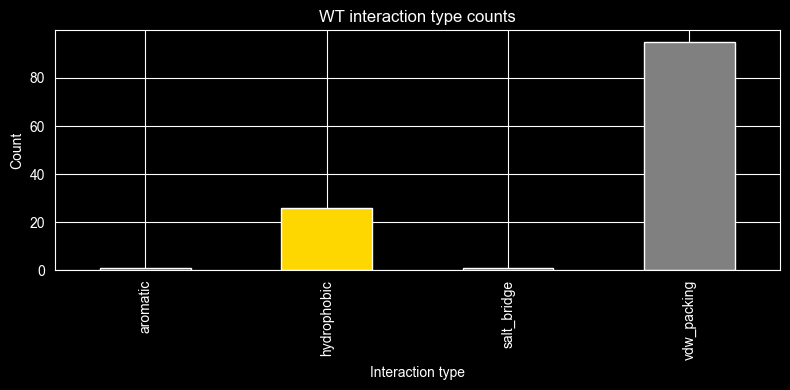

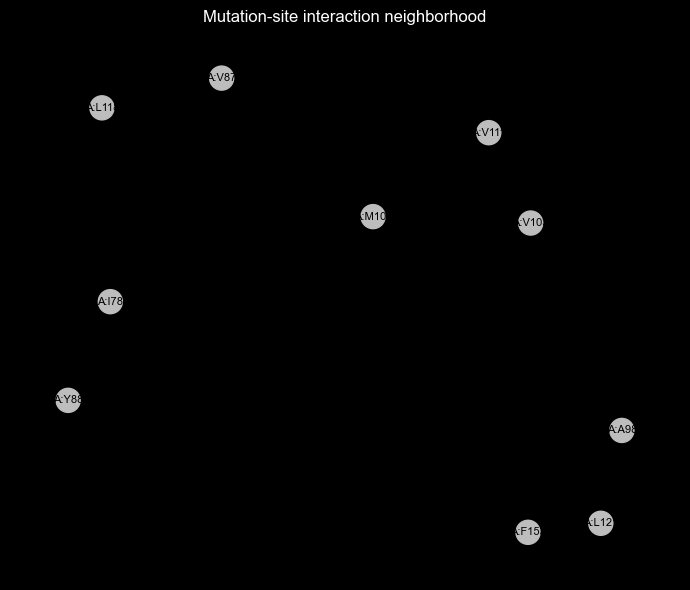

In [8]:
figures = {}

def plot_interaction_summary(interactions: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 4))
    if interactions.empty:
        ax.text(0.5, 0.5, "No WT interactions detected", ha="center", va="center")
        ax.axis("off")
    else:
        counts = interactions["interaction_type"].value_counts().sort_index()
        colors = [INTERACTION_COLORS.get(k, "grey") for k in counts.index]
        counts.plot(kind="bar", ax=ax, color=colors)
        ax.set_title("WT interaction type counts")
        ax.set_xlabel("Interaction type")
        ax.set_ylabel("Count")
    fig.tight_layout()
    return fig


def plot_local_network(graph: nx.MultiGraph, residues: pd.DataFrame, mutation_uid: str | None):
    fig, ax = plt.subplots(figsize=(7, 6))
    if not mutation_uid or mutation_uid not in graph:
        ax.text(0.5, 0.5, "No valid mutation site for local network", ha="center", va="center")
        ax.axis("off")
        fig.tight_layout()
        return fig
    nodes = mutation_neighborhood_residue_uids(residues, mutation_uid) & set(graph.nodes())
    if not nodes:
        nodes = {mutation_uid} | set(graph.neighbors(mutation_uid))
    sub = graph.subgraph(nodes)
    simple = nx.Graph()
    for u, v, data in sub.edges(data=True):
        simple.add_edge(u, v, weight=abs(float(data.get("relative_weight", 0.1))))
    labels = {n: graph.nodes[n].get("residue_label", n) for n in simple.nodes}
    pos = nx.spring_layout(simple, seed=7) if len(simple) else {}
    node_colors = ["#FFC107" if n == mutation_uid else "#BDBDBD" for n in simple.nodes]
    nx.draw_networkx(simple, pos=pos, labels=labels, node_color=node_colors, font_size=8, ax=ax)
    ax.set_title("Mutation-site interaction neighborhood")
    ax.axis("off")
    fig.tight_layout()
    return fig


figures["interaction_summary"] = plot_interaction_summary(wt_interactions)
figures["local_network"] = plot_local_network(wt_graph, residue_table, mutation_uid)
plt.show()

In [9]:
mvs_states = {}
mvs_summary = []

def molstar_url_from_state_dict(state_dict: dict[str, Any]) -> str:
    encoded = base64.b64encode(json.dumps(state_dict).encode()).decode()
    return f"https://molstar.org/viewer/?mvs-data={encoded}&mvs-data-format=mvsj"


def show_mol_view(state, label, width=950, height=600):
    if display is None:
        print(f"MolViewSpec state generated: {label}")
        return
    try:
        html = state.molstar_html()
        encoded = base64.b64encode(html.encode()).decode()
        display(HTML(f"<div style='font-weight:bold;margin:8px 0 4px'>{label}</div>"))
        display(IFrame(src=f"data:text/html;base64,{encoded}", width=width, height=height))
    except Exception:
        state_dict = state.as_dict() if hasattr(state, "as_dict") else state.to_dict()
        display(HTML(f"<b>{label}</b><br><a href='{molstar_url_from_state_dict(state_dict)}' target='_blank'>Open in Mol* viewer</a>"))


def try_build_molviewspec_views(payload: dict[str, Any], residues: pd.DataFrame, validation: dict[str, Any]) -> None:
    if not payload.get("structure_url"):
        mvs_summary.append({"view": "all", "status": "skipped", "reason": "No public structure URL available"})
        return
    try:
        import molviewspec as mvs
        version = getattr(mvs, "__version__", "unknown")
        has_builder = hasattr(mvs, "create_builder")
        has_expr = hasattr(mvs, "ComponentExpression")
        if not (has_builder and has_expr):
            raise RuntimeError("Installed MolViewSpec API lacks create_builder or ComponentExpression")
        log_event("info", "MolViewSpec API available", version=version)
    except ImportError as exc:
        mvs_summary.append({"view": "all", "status": "skipped", "reason": "molviewspec not installed"})
        log_event("warning", "MolViewSpec skipped: not installed", error=str(exc))
        return
    except Exception as exc:
        mvs_summary.append({"view": "all", "status": "skipped", "reason": str(exc)})
        log_event("warning", "MolViewSpec API verification failed", error=str(exc))
        return

    parse_candidates = ["mmcif", "cif"] if payload.get("structure_format") in {"mmcif", "cif"} else [payload.get("structure_format", "mmcif")]
    try:
        builder = mvs.create_builder()
        structure_node = None
        accepted_format = None
        last_error = None
        for fmt in parse_candidates:
            try:
                structure_node = builder.download(url=payload["structure_url"]).parse(format=fmt).model_structure()
                accepted_format = fmt
                break
            except Exception as exc:
                last_error = exc
        if structure_node is None:
            raise RuntimeError(f"No accepted MolViewSpec parse format. Last error: {last_error}")
        structure_node.component().representation(type="cartoon").color(color="#BDBDBD")
        if validation.get("valid") and hasattr(mvs, "ComponentExpression"):
            expr = mvs.ComponentExpression(
                label_asym_id=str(validation["chain_id"]),
                beg_label_seq_id=int(validation["residue_number"]),
                end_label_seq_id=int(validation["residue_number"]),
            )
            structure_node.component(selector=expr).representation(type="ball_and_stick").color(color="#FFC107")
        state = builder.get_state()
        mvs_states["chain_overview"] = state.as_dict() if hasattr(state, "as_dict") else state.to_dict()
        mvs_summary.append({"view": "chain_overview", "status": "generated", "format": accepted_format})
        try:
            show_mol_view(state, "MolViewSpec chain overview and mutation focus")
        except Exception as exc:
            log_event("warning", "MolViewSpec inline display failed; state retained for Mol* fallback", error=str(exc))
    except Exception as exc:
        mvs_summary.append({"view": "chain_overview", "status": "skipped", "reason": str(exc)})
        log_event("warning", "MolViewSpec chain overview failed", error=str(exc))


try_build_molviewspec_views(structure_payload, residue_table, mutation_validation)
pd.DataFrame(mvs_summary)

,view,status,format
0,chain_overview,generated,mmcif


## 9. Mechanistic Interpretation

The summary separates computed observations from mechanistic interpretation and higher-level hypotheses. The wording is intentionally cautious.

In [10]:
def build_mechanistic_summary(delta: pd.DataFrame, validation: dict[str, Any], severity: dict[str, Any], confidence: dict[str, Any]) -> pd.DataFrame:
    rows = []
    if not validation.get("valid"):
        return pd.DataFrame([
            {
                "layer": "observation",
                "statement": f"Mutation validation failed: {validation.get('error')}",
                "supporting_records": validation.get("raw_notation", ""),
                "confidence": "high",
                "caveat": "No mutation perturbation analysis was run.",
            }
        ])
    if delta.empty:
        rows.append({
            "layer": "observation",
            "statement": "No v1 perturbation records were generated for the validated mutation.",
            "supporting_records": validation.get("residue_uid", ""),
            "confidence": "low",
            "caveat": "Absence of detected interactions is not evidence of no structural effect.",
        })
    else:
        for _, rec in delta.iterrows():
            rows.append({
                "layer": "observation",
                "statement": rec["observation_text"],
                "supporting_records": rec["delta_id"],
                "confidence": rec["confidence"],
                "caveat": "Computed from heuristic interaction detection.",
            })
            rows.append({
                "layer": "interpretation",
                "statement": rec["interpretation_text"],
                "supporting_records": rec["delta_id"],
                "confidence": rec["confidence"],
                "caveat": "This is structural compatibility reasoning, not exact energetics.",
            })
    rows.append({
        "layer": "hypothesis",
        "statement": f"Structural disruption likelihood is {severity['severity']} because {severity['rationale']}",
        "supporting_records": ",".join(delta["delta_id"].astype(str).tolist()) if not delta.empty else validation.get("residue_uid", ""),
        "confidence": "low" if confidence.get("structure_confidence", "").startswith("low") else "moderate",
        "caveat": severity.get("calibration", "uncalibrated; non-clinical"),
    })
    if confidence.get("unsupported_context"):
        rows.append({
            "layer": "hypothesis",
            "statement": "Unsupported ligand, metal, glycan, membrane, or assembly context may affect interpretation.",
            "supporting_records": "; ".join(confidence["unsupported_context"]),
            "confidence": "low",
            "caveat": "V1 does not model ligand, cofactor, PTM, metal, membrane, solvent, allostery, or ensemble energetics.",
        })
    return pd.DataFrame(rows)


mechanistic_summary = build_mechanistic_summary(compatibility_delta, mutation_validation, severity_summary, confidence_summary)
forbidden = re.compile(r"\b(pathogenic|benign|diagnos|disease severity|guarantees|causes unfolding|ddG)\b", re.I)
forbidden_hits = [s for s in mechanistic_summary["statement"].astype(str) if forbidden.search(s)]
if forbidden_hits:
    log_event("error", "Forbidden interpretation language detected", hits=forbidden_hits)

display(mechanistic_summary) if display else print(mechanistic_summary)

,layer,statement,supporting_records,confidence,caveat
0,observation,WT local interaction detected: hydrophobic wit...,D0001,moderate,Computed from heuristic interaction detection.
1,interpretation,L->A substantially reduces sidechain volume ne...,D0001,moderate,"This is structural compatibility reasoning, no..."
2,observation,WT local interaction detected: vdw_packing wit...,D0002,moderate,Computed from heuristic interaction detection.
3,interpretation,L->A substantially reduces sidechain volume ne...,D0002,moderate,"This is structural compatibility reasoning, no..."
4,observation,WT local interaction detected: hydrophobic wit...,D0003,moderate,Computed from heuristic interaction detection.
5,interpretation,L->A substantially reduces sidechain volume ne...,D0003,moderate,"This is structural compatibility reasoning, no..."
6,observation,WT local interaction detected: vdw_packing wit...,D0004,moderate,Computed from heuristic interaction detection.
7,interpretation,L->A substantially reduces sidechain volume ne...,D0004,moderate,"This is structural compatibility reasoning, no..."
8,observation,WT local interaction detected: hydrophobic wit...,D0005,moderate,Computed from heuristic interaction detection.
9,interpretation,L->A substantially reduces sidechain volume ne...,D0005,moderate,"This is structural compatibility reasoning, no..."


## 10. Export Bundle

Exports are assembled in memory by default. Set `WRITE_EXPORTS = True` in the setup cell to write JSON, CSV, SVG/PNG, graph edge/node data, and optional `.mvsj` files.

In [11]:
def df_to_csv_text(df: pd.DataFrame) -> str:
    return df.to_csv(index=False) if isinstance(df, pd.DataFrame) else ""


export_bundle = {
    "fixture_id": FIXTURE_ID,
    "structure_request": structure_request,
    "provenance": provenance,
    "analysis_status": analysis_status,
    "residue_table_csv": df_to_csv_text(residue_table),
    "wt_interactions_csv": df_to_csv_text(wt_interactions),
    "mutant_compatibility_delta_csv": df_to_csv_text(compatibility_delta),
    "network_metrics_csv": df_to_csv_text(wt_network_metrics),
    "mechanistic_summary_csv": df_to_csv_text(mechanistic_summary),
    "severity_summary": severity_summary,
    "notebook_log": notebook_log,
    "mvs_states": mvs_states,
}

if WRITE_EXPORTS:
    EXPORT_DIR.mkdir(exist_ok=True)
    prefix = f"{FIXTURE_ID}_{structure_request['identifier']}_{structure_request['mutation_notation'].replace(':', '-')}"
    (EXPORT_DIR / f"{prefix}_summary.json").write_text(json.dumps(export_bundle, indent=2, default=str))
    residue_table.to_csv(EXPORT_DIR / f"{prefix}_residues.csv", index=False)
    wt_interactions.to_csv(EXPORT_DIR / f"{prefix}_wt_interactions.csv", index=False)
    compatibility_delta.to_csv(EXPORT_DIR / f"{prefix}_compatibility_delta.csv", index=False)
    wt_network_metrics.to_csv(EXPORT_DIR / f"{prefix}_network_metrics.csv", index=False)
    mechanistic_summary.to_csv(EXPORT_DIR / f"{prefix}_mechanistic_summary.csv", index=False)
    for name, fig in figures.items():
        fig.savefig(EXPORT_DIR / f"{prefix}_{name}.png", dpi=180, bbox_inches="tight")
        fig.savefig(EXPORT_DIR / f"{prefix}_{name}.svg", bbox_inches="tight")
    for name, state in mvs_states.items():
        (EXPORT_DIR / f"{prefix}_{name}.mvsj").write_text(json.dumps(state, indent=2, default=str))
    log_event("info", "Export files written", path=str(EXPORT_DIR))

pd.DataFrame([{
    "fixture_id": FIXTURE_ID,
    "residue_rows": len(residue_table),
    "interaction_rows": len(wt_interactions),
    "delta_rows": len(compatibility_delta),
    "summary_rows": len(mechanistic_summary),
    "mvs_states": len(mvs_states),
    "write_exports": WRITE_EXPORTS,
}])

,fixture_id,residue_rows,interaction_rows,delta_rows,summary_rows,mvs_states,write_exports
0,FX-001,164,123,26,53,1,False


## 11. Internal Validation Snapshot

This section summarizes fixture-aware checks. It is not a substitute for `$notebook-execution-validation`; it records the assumptions and checks needed for that later stage.

In [12]:
def check(name: str, passed: bool, detail: str = "") -> dict[str, Any]:
    return {"check": name, "passed": bool(passed), "detail": detail}


validation_rows = [
    check("fixture selected", FIXTURE_ID in FIXTURES, FIXTURE_ID),
    check("retrieval status recorded", bool(provenance) or bool(analysis_status["errors"]), str(analysis_status["errors"][:1])),
    check("config mutation radius is 8A", CONFIG["mutation_radius_angstrom"] == 8.0, str(CONFIG["mutation_radius_angstrom"])),
    check("forbidden language absent", not forbidden_hits, str(forbidden_hits[:3])),
    check("MolViewSpec optional state respected", True, "No required downstream cell depends on mvs_states"),
]
if FIXTURE_ID == "FX-001":
    validation_rows += [
        check("FX-001 PDB ID", structure_payload.get("identifier", "").upper() == "2LZM", structure_payload.get("identifier", "")),
        check("FX-001 mutation validates", bool(mutation_validation.get("valid")), mutation_validation.get("error", "")),
        check("FX-001 local interactions present", len(local_interactions_for_mutation(residue_table, wt_interactions, mutation_uid)) > 0 if mutation_uid else False, "exact count frozen after trusted run"),
    ]
elif FIXTURE_ID == "FX-002":
    validation_rows += [
        check("FX-002 AFDB source", structure_payload.get("source") == "afdb", structure_payload.get("source", "")),
        check("FX-002 confidence downgraded", str(confidence_summary.get("structure_confidence", "")).startswith("low") or confidence_summary.get("low_confidence_residue_count", 0) > 0, str(confidence_summary)),
    ]
elif FIXTURE_ID == "FX-005":
    validation_rows += [
        check("FX-005 retrieval fails gracefully", bool(analysis_status["errors"]), str(analysis_status["errors"][:1])),
        check("FX-005 parsing skipped", residue_table.empty, "negative fixture"),
    ]
elif FIXTURE_ID == "FX-006":
    validation_rows += [
        check("FX-006 mutation mismatch detected", not mutation_validation.get("valid") and "mismatch" in mutation_validation.get("error", "").lower(), mutation_validation.get("error", "")),
    ]

validation_summary = pd.DataFrame(validation_rows)
display(validation_summary) if display else print(validation_summary)
print(f"Notebook runtime so far: {time.time() - NOTEBOOK_START:.2f} seconds")

,check,passed,detail
0,fixture selected,True,FX-001
1,retrieval status recorded,True,[]
2,config mutation radius is 8A,True,8.0
3,forbidden language absent,True,[]
4,MolViewSpec optional state respected,True,No required downstream cell depends on mvs_states
5,FX-001 PDB ID,True,2LZM
6,FX-001 mutation validates,True,
7,FX-001 local interactions present,True,exact count frozen after trusted run


Notebook runtime so far: 4.84 seconds


## 12. Reuse And Adaptation Notes

To run another pinned fixture, change `FIXTURE_ID` in the setup cell to one of `FX-001` through `FX-007` and restart-run-all.

To analyze a new structure, update `structure_request` with `source`, `identifier`, and `mutation_notation`, then restart-run-all. New results should be treated as research-use structural hypotheses until fixtures and domain review are added.

Known limitations:

- The mutation model is sidechain-substitution-only and does not predict exact mutant coordinates.
- Interaction weights are relative heuristics, not kcal/mol, free energy, or ddG.
- Severity labels are uncalibrated structural disruption likelihood labels.
- Ligands, metals, glycans, PTMs, membrane context, solvent, dynamics, allostery, and ensemble effects are not modeled in V1.